# Nexus Business Assistant — Three-Tier Memory

A LangGraph agent with a three-tier memory architecture:

| Tier | Name | Source | Injected |
|------|------|--------|----------|
| **1** | Stable Persona | `persona.json` (manual) + Mem0 (auto-learned patterns) | Always |
| **2** | Session Working Memory | LangGraph `SqliteSaver` checkpointer | Always |
| **3** | Deep Knowledge Base | Supermemory (semantic search) | Only if similarity ≥ 0.78 |

**Required:** `NVIDIA_API_KEY`  
**Optional:** `MEM0_API_KEY` (Tier 1B disabled without it), `SUPERMEMORY_API_KEY` (Tier 3 disabled without it)

## Setup & Config

In [1]:
import json
import os
import sqlite3
import uuid
from datetime import datetime, timedelta, timezone
from pathlib import Path
from typing import Annotated, List, TypedDict

from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langgraph.graph import END, START, StateGraph

PROJECT_ROOT = Path.cwd()
for _candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (_candidate / "memory" / "persona.json").exists():
        PROJECT_ROOT = _candidate
        break

load_dotenv(dotenv_path=PROJECT_ROOT / ".env")

PERSONA_JSON_PATH = PROJECT_ROOT / "memory" / "persona.json"
SESSION_DB_PATH = PROJECT_ROOT / "data" / "sessions.sqlite"

# ── Identity ────────────────────────────────────────────────────────────
NEXUS_USER_ID = os.getenv("NEXUS_USER_ID", "default_user")

# ── Tier settings ──────────────────────────────────────────────────────
SESSION_TTL_HOURS = 48
KNOWLEDGE_THRESHOLD = 0.78

# Rough character budgets per tier (~4 chars ≈ 1 token)
TOKEN_BUDGET = {"tier1": 3200, "tier2": 2400, "tier3": 2400}

# ── Trigger phrases ────────────────────────────────────────────────────
DAILY_CHECKUP_PHRASES = (
    "daily checkup", "daily check-in", "daily briefing",
    "morning briefing", "what is on my schedule", "check my day",
)

print(f"Project root: {PROJECT_ROOT}")
print(f"User ID: {NEXUS_USER_ID}")

Project root: /Users/asmitkaushal/Projects/Nexus
User ID: default_user


## LLM (required — NVIDIA)

In [2]:
if not os.getenv("NVIDIA_API_KEY"):
    raise EnvironmentError("NVIDIA_API_KEY is not set. Nexus requires an LLM to run.")

llm = ChatNVIDIA(
    model=os.getenv("NEXUS_MODEL", "meta/llama-3.1-8b-instruct"),
    temperature=0.2,
)
print(f"LLM: {llm.model}")

LLM: meta/llama-3.1-8b-instruct


## Tier 1 — Stable Persona

**Part A:** `persona.json` — manually curated ground truth. Code reads, never writes.  
**Part B:** Mem0 — auto-extracts behavioral patterns from every conversation turn.  

Both parts are loaded and injected **unconditionally** on every agent call.

In [17]:
# ── Tier 1A: persona.json ──────────────────────────────────────────────

def load_persona_json() -> dict:
    """Read the ground-truth persona file. Returns empty dict if missing."""
    if not PERSONA_JSON_PATH.exists():
        print("persona.json not found — using empty persona.")
        return {}
    with open(PERSONA_JSON_PATH, "r", encoding="utf-8") as f:
        return json.load(f)


def format_persona(data: dict) -> str:
    """Turn the persona dict into a readable text block for the prompt."""
    if not data:
        return "No persona file configured."
    lines = []
    field_labels = {
        "name": "Name",
        "role": "Role",
        "current_projects": "Current projects",
        "long_term_goals": "Long-term goals",
        "working_style": "Working style",
        "communication_preferences": "Communication preferences",
        "tools": "Tools",
        "timezone": "Timezone",
        "custom_notes": "Notes",
    }
    for key, label in field_labels.items():
        value = data.get(key)
        if value is None:
            continue
        if isinstance(value, list):
            lines.append(f"{label}: {', '.join(value)}")
        else:
            lines.append(f"{label}: {value}")
    return "\n".join(lines)


# ── Tier 1B: Mem0 (learned patterns) ───────────────────────────────────

class Mem0Patterns:
    """Thin wrapper around Mem0 for auto-learned behavioral patterns.
    Uses the v2 API where user_id goes inside filters, not as a top-level kwarg."""

    def __init__(self):
        self.client = None
        api_key = os.getenv("MEM0_API_KEY")
        if not api_key:
            print("Tier 1B (Mem0): disabled — MEM0_API_KEY not set")
            return
        try:
            from mem0 import MemoryClient
            self.client = MemoryClient(api_key=api_key)
            print("Tier 1B (Mem0): enabled")
        except Exception as exc:
            print(f"Tier 1B (Mem0): disabled — {exc}")

    @property
    def enabled(self) -> bool:
        return self.client is not None

    def search(self, query: str, *, user_id: str = None, limit: int = 6) -> List[str]:
        """Search Mem0 for patterns relevant to the current input."""
        if not self.enabled:
            return []
        uid = user_id or NEXUS_USER_ID
        try:
            raw = self.client.search(
                query,
                filters={"user_id": uid},
                top_k=limit,
            )
        except Exception as exc:
            print(f"Mem0 search failed: {exc}")
            return []
        return self._extract_texts(raw)[:limit]

    def add(self, user_input: str, assistant_answer: str, *, user_id: str = None) -> None:
        """Persist a conversation turn so Mem0 can extract patterns."""
        if not self.enabled:
            return
        uid = user_id or NEXUS_USER_ID
        try:
            self.client.add(
                [{"role": "user", "content": user_input},
                 {"role": "assistant", "content": assistant_answer}], user_id=uid,
            )
        except Exception as exc:
            print(f"Mem0 write failed: {exc}")

    @staticmethod
    def _extract_texts(raw) -> List[str]:
        """Normalize Mem0's response (handles multiple API versions)."""
        if raw is None:
            return []
        if isinstance(raw, dict):
            raw = raw.get("results") or raw.get("memories") or raw.get("data") or []
        if not isinstance(raw, list):
            raw = [raw]
        texts = []
        for item in raw:
            text = (
                item.get("memory") or item.get("content") or item.get("text")
                if isinstance(item, dict) else str(item)
            )
            if text:
                texts.append(text)
        return texts


# ── Tier 1: Combined accessor ──────────────────────────────────────────

mem0 = Mem0Patterns()


def get_tier1_context(user_input: str) -> str:
    """Load persona.json + Mem0 patterns into a single formatted block."""
    persona_text = format_persona(load_persona_json())
    patterns = mem0.search(user_input, )
    patterns_text = (
        "\n".join(f"- {p}" for p in patterns) if patterns
        else "No learned patterns yet."
    )
    return f"{persona_text}\n\nLearned patterns:\n{patterns_text}"


# Quick test
print("--- Tier 1 preview ---")
print(get_tier1_context("test"))

Tier 1B (Mem0): enabled
--- Tier 1 preview ---
Name: Asmit
Role: Founder / Builder
Current projects: Nexus AI business assistant
Long-term goals: Build an AI first personal OS
Working style: Deep work blocks, async communication preferred
Communication preferences: Concise, no fluff, action oriented
Tools: VS Code, Notion, GitHub
Timezone: Asia/Kolkata
Notes: Prefers bullet points over paragraphs

Learned patterns:
- User's task on 2026-07-01 is to create a multi-agentic agent.
- Assistant gave a step-by-step guide for building a multi-agentic agent, advising to define roles (Data Collector, Analyst, Decision Maker, Executor), select appropriate architectures (ABM, cognitive, MAS), design interactions (message passing, shared memory, auctions, negotiation), implement logic in Python or Java, use libraries such as PyNS2 or JADE, and test with simulation tools like AnyLogic or SimPy.


## Tier 2 — Session Working Memory

Backed by a LangGraph `SqliteSaver` checkpointer. Captures the full conversation
state automatically on every node. Expires after 48 hours. Always injected.

In [18]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

# Ensure the data directory exists
SESSION_DB_PATH.parent.mkdir(parents=True, exist_ok=True)

conn = sqlite3.connect(str(SESSION_DB_PATH), check_same_thread=False)
checkpointer = SqliteSaver(conn)



def generate_session_id() -> str:
    """Create a new session UUID."""
    return uuid.uuid4().hex[:12]


def get_thread_config(session_id: str) -> dict:
    """Build the LangGraph config dict that routes to this session's checkpoint."""
    return {"configurable": {"thread_id": f"{NEXUS_USER_ID}:{session_id}"}}


def cleanup_expired_sessions():
    """Delete checkpoint threads older than SESSION_TTL_HOURS.
    Runs once at the start of each new session."""
    try:
        cutoff = datetime.now(timezone.utc) - timedelta(hours=SESSION_TTL_HOURS)
        conn = sqlite3.connect(str(SESSION_DB_PATH))
        cursor = conn.cursor()
        # SqliteSaver stores checkpoints with a 'thread_id' and 'created_at' column
        cursor.execute(
            "SELECT name FROM sqlite_master WHERE type='table' AND name='checkpoints'"
        )
        if cursor.fetchone():
            cursor.execute(
                "DELETE FROM checkpoints WHERE thread_id IN "
                "(SELECT DISTINCT thread_id FROM checkpoints "
                " WHERE thread_ts < ?)",
                (cutoff.isoformat(),),
            )
            deleted = cursor.rowcount
            conn.commit()
            if deleted > 0:
                print(f"Cleaned up {deleted} expired checkpoint rows.")
        conn.close()
    except Exception as exc:
        print(f"Session cleanup skipped: {exc}")


def get_tier2_context(state: dict) -> str:
    """Format the session's conversation history for injection into the prompt."""
    history = state.get("conversation_history", [])
    current_task = state.get("current_task", "")

    parts = []
    if current_task:
        parts.append(f"Current task: {current_task}")

    if history:
        parts.append("Recent conversation:")
        # Show last 8 turns to stay within budget
        for turn in history[-8:]:
            role = turn.get("role", "unknown")
            content = turn.get("content", "")
            label = "You" if role == "user" else "Nexus"
            parts.append(f"  [{label}]: {content}")
    else:
        parts.append("No conversation history yet (new session).")

    return "\n".join(parts)


# Run cleanup on startup
cleanup_expired_sessions()
print(f"Tier 2 (Session): checkpointer ready at {SESSION_DB_PATH}")

Session cleanup skipped: no such column: thread_ts
Tier 2 (Session): checkpointer ready at /Users/asmitkaushal/Projects/Nexus/data/sessions.sqlite


## Tier 3 — Deep Knowledge Base (Supermemory)

Growing store of decisions, lessons, and synced content (Notion, GitHub).  
Only injected when semantic search returns results above the **0.78** similarity threshold.

In [5]:
class KnowledgeBase:
    """Thin wrapper around Supermemory for the deep knowledge tier.
    Returns empty results gracefully when the API key is missing."""

    def __init__(self):
        self.client = None
        api_key = os.getenv("SUPERMEMORY_API_KEY")
        if not api_key:
            print("Tier 3 (Supermemory): disabled — SUPERMEMORY_API_KEY not set")
            return
        try:
            from supermemory import Supermemory
            self.client = Supermemory(api_key=api_key)
            print("Tier 3 (Supermemory): enabled")
        except Exception as exc:
            print(f"Tier 3 (Supermemory): disabled — {exc}")

    @property
    def enabled(self) -> bool:
        return self.client is not None

    def search(
        self,
        query: str,
        *,
        threshold: float = KNOWLEDGE_THRESHOLD,
        limit: int = 5,
    ) -> List[dict]:
        """Semantic search. Returns only results above the similarity threshold.
        Each result dict has keys: 'content' and 'similarity'."""
        if not self.enabled:
            return []
        try:
            response = self.client.search.execute(
                q=query,
                container_tag=NEXUS_USER_ID,
                limit=limit,
            )
            results = []
            for item in (response.results or []):
                # Extract content and similarity score
                content = getattr(item, "memory", None) or getattr(item, "chunk", None) or str(item)
                similarity = getattr(item, "similarity", 0.0)
                if similarity >= threshold:
                    results.append({"content": content, "similarity": round(similarity, 2)})
            return results
        except Exception as exc:
            print(f"Supermemory search failed: {exc}")
            return []

    def add(self, content: str, *, metadata: dict = None) -> None:
        """Write a knowledge entry (e.g. session summary) to Supermemory."""
        if not self.enabled:
            return
        try:
            self.client.add(
                content=content,
                container_tag=NEXUS_USER_ID,
                metadata=metadata or {},
            )
        except Exception as exc:
            print(f"Supermemory write failed: {exc}")


knowledge_base = KnowledgeBase()


def get_tier3_context(user_input: str) -> str:
    """Search Supermemory. Returns formatted block or empty string."""
    results = knowledge_base.search(user_input)
    if not results:
        return ""  # Nothing above threshold — tier stays empty
    lines = []
    for r in results:
        lines.append(f"- [{r['similarity']}] {r['content']}")
    return "\n".join(lines)

Tier 3 (Supermemory): disabled — SUPERMEMORY_API_KEY not set


## Prompt Builder — Single Assembly Function

Combines all three tiers in order, enforces token budgets, returns one string.

In [6]:
def _truncate(text: str, char_budget: int) -> str:
    """Hard-truncate text to a character budget with an ellipsis marker."""
    if len(text) <= char_budget:
        return text
    return text[:char_budget - 20] + "\n... [truncated]"


def build_system_prompt(user_input: str, state: dict) -> str:
    """Assemble the final system prompt from all three memory tiers.

    Tier 1 and 2 are always included.
    Tier 3 is only included if Supermemory returns results above threshold.
    Each tier is capped to its token budget.
    """
    # ── Tier 1: always ─────────────────────────────────────────────────
    t1 = _truncate(get_tier1_context(user_input), TOKEN_BUDGET["tier1"])

    # ── Tier 2: always ─────────────────────────────────────────────────
    t2 = _truncate(get_tier2_context(state), TOKEN_BUDGET["tier2"])

    # ── Tier 3: conditional ────────────────────────────────────────────
    t3_raw = get_tier3_context(user_input)
    t3 = _truncate(t3_raw, TOKEN_BUDGET["tier3"]) if t3_raw else ""

    # ── Assemble ───────────────────────────────────────────────────────
    sections = [
        f"## Identity & Patterns (Tier 1)\n{t1}",
        f"## Current Session (Tier 2)\n{t2}",
    ]
    if t3:
        sections.append(f"## Relevant Knowledge (Tier 3)\n{t3}")

    return "\n\n".join(sections)


# Quick preview with empty state
print("--- System prompt preview ---")
print(build_system_prompt("test query", {}))

--- System prompt preview ---
## Identity & Patterns (Tier 1)
Name: Asmit
Role: Founder / Builder
Current projects: Nexus AI business assistant
Long-term goals: Build an AI first personal OS
Working style: Deep work blocks, async communication preferred
Communication preferences: Concise, no fluff, action oriented
Tools: VS Code, Notion, GitHub
Timezone: Asia/Kolkata
Notes: Prefers bullet points over paragraphs

Learned patterns:
- User's task on 2026-07-01 is to create a multi-agentic agent.
- Assistant gave a step-by-step guide for building a multi-agentic agent, advising to define roles (Data Collector, Analyst, Decision Maker, Executor), select appropriate architectures (ABM, cognitive, MAS), design interactions (message passing, shared memory, auctions, negotiation), implement logic in Python or Java, use libraries such as PyNS2 or JADE, and test with simulation tools like AnyLogic or SimPy.

## Current Session (Tier 2)
No conversation history yet (new session).


## MCP Tool Placeholders

In [7]:
def check_calendar() -> str:
    # TODO: Connect calendar MCP tool
    return "Calendar MCP tool is not connected yet."


def check_email() -> str:
    # TODO: Connect email MCP tool
    return "Email MCP tool is not connected yet."


def check_other_tools() -> str:
    # TODO: Connect tasks, docs, CRM, or other MCP tools
    return "Additional business MCP tools are not connected yet."

## State & Helpers

In [8]:
class NexusState(TypedDict, total=False):
    # Core
    user_input: str
    session_id: str

    # Tier 1
    system_prompt: str

    # Tier 2 — persisted by checkpointer
    conversation_history: List[dict]  # [{"role": ..., "content": ...}, ...]
    current_task: str

    # Routing flags
    daily_checkup_needed: bool
    tool_results: List[str]

    # Answer pipeline
    answer: str
    relevance_passed: bool
    relevance_reason: str
    final_answer: str


def _matches_any(text: str, phrases: tuple) -> bool:
    lowered = text.lower()
    return any(p in lowered for p in phrases)


def _format_list(items: List[str], fallback: str = "None.") -> str:
    if not items:
        return fallback
    return "\n".join(f"- {item}" for item in items)

## Graph Nodes

```
START → load_context → [daily checkup?] → generate_answer
      → check_relevance → [repair?] → persist_memory → END
```

In [9]:
def load_context(state: NexusState) -> NexusState:
    """Build the three-tier system prompt and set routing flags."""
    user_input = state["user_input"]

    # Append current turn to conversation history
    history = list(state.get("conversation_history", []))
    history.append({"role": "user", "content": user_input})

    # Build combined system prompt from all three tiers
    prompt = build_system_prompt(user_input, {**state, "conversation_history": history})

    return {
        **state,
        "system_prompt": prompt,
        "conversation_history": history,
        "daily_checkup_needed": _matches_any(user_input, DAILY_CHECKUP_PHRASES),
    }


def run_daily_checkup(state: NexusState) -> NexusState:
    """Call all daily-checkup MCP tool placeholders."""
    return {
        **state,
        "tool_results": [check_calendar(), check_email(), check_other_tools()],
    }


def generate_answer(state: NexusState) -> NexusState:
    """Call the LLM with the assembled three-tier system prompt.
    All context is merged into ONE SystemMessage so the LLM actually uses it."""
    tool_block = _format_list(state.get("tool_results", []))

    # ── Single consolidated system message ────────────────────────────
    # Many models (especially smaller ones like llama-3.1-8b) ignore all
    # but the first SystemMessage. Merging everything into one ensures
    # the persona, session history, and knowledge all reach the model.
    system_content = "\n\n".join([
        (
            "You are Nexus, the user's business assistant. "
            "You MUST use the identity, patterns, and preferences below "
            "to personalize every response. Address the user by name. "
            "Be concise, practical, and action-oriented. "
            "Be explicit about uncertainty. Never claim calendar, email, or "
            "MCP results unless they appear in the tool results section."
        ),
        state.get("system_prompt", ""),
        f"## Tool Results\n{tool_block}",
    ])

    messages = [
        SystemMessage(content=system_content),
        HumanMessage(content=state["user_input"]),
    ]
    response = llm.invoke(messages)
    return {**state, "answer": response.content}



def check_relevance(state: NexusState) -> NexusState:
    """Quality gate — ask the LLM if the answer addresses the request."""
    messages = [
        SystemMessage(content=(
            "You are a strict relevance grader. Reply only with PASS or FAIL, "
            "followed by a short reason. PASS means the answer directly "
            "addresses the user's request."
        )),
        HumanMessage(content=(
            f"User request:\n{state['user_input']}\n\n"
            f"Answer:\n{state.get('answer', '')}"
        )),
    ]
    result = llm.invoke(messages).content.strip()
    return {
        **state,
        "relevance_passed": result.upper().startswith("PASS"),
        "relevance_reason": result,
    }


def repair_answer(state: NexusState) -> NexusState:
    """Rewrite an answer that failed the relevance check."""
    messages = [
        SystemMessage(content="Rewrite the answer so it directly satisfies the user's request."),
        HumanMessage(content=(
            f"User request:\n{state['user_input']}\n\n"
            f"Previous answer:\n{state.get('answer', '')}\n\n"
            f"Relevance issue:\n{state.get('relevance_reason', '')}"
        )),
    ]
    response = llm.invoke(messages)
    return {**state, "final_answer": response.content}


def persist_memory(state: NexusState) -> NexusState:
    """End-of-turn writes:
    - Tier 1B: Save conversation turn to Mem0 for pattern learning.
    - Tier 2: Append assistant response to conversation history
              (checkpointer auto-persists the full state).
    """
    final = state.get("final_answer") or state.get("answer", "")

    # Tier 1B write — Mem0 pattern learning
    mem0.add(state["user_input"], final)

    # Tier 2 — append assistant turn to history (checkpointer saves automatically)
    history = list(state.get("conversation_history", []))
    history.append({"role": "assistant", "content": final})

    return {**state, "final_answer": final, "conversation_history": history}

## Build the Graph

In [10]:
def _route_after_context(state: NexusState) -> str:
    if state.get("daily_checkup_needed"):
        return "run_daily_checkup"
    return "generate_answer"


def _route_after_relevance(state: NexusState) -> str:
    return "persist_memory" if state.get("relevance_passed") else "repair_answer"


# ── Assemble ────────────────────────────────────────────────────────────

graph = StateGraph(NexusState)

graph.add_node("load_context", load_context)
graph.add_node("run_daily_checkup", run_daily_checkup)
graph.add_node("generate_answer", generate_answer)
graph.add_node("check_relevance", check_relevance)
graph.add_node("repair_answer", repair_answer)
graph.add_node("persist_memory", persist_memory)

graph.add_edge(START, "load_context")

graph.add_conditional_edges("load_context", _route_after_context, {
    "run_daily_checkup": "run_daily_checkup",
    "generate_answer": "generate_answer",
})

graph.add_edge("run_daily_checkup", "generate_answer")
graph.add_edge("generate_answer", "check_relevance")

graph.add_conditional_edges("check_relevance", _route_after_relevance, {
    "persist_memory": "persist_memory",
    "repair_answer": "repair_answer",
})

graph.add_edge("repair_answer", "persist_memory")
graph.add_edge("persist_memory", END)

# Compile WITH checkpointer for Tier 2 session persistence
nexus_agent = graph.compile(checkpointer=checkpointer)
print("Graph compiled with checkpointer.")

Graph compiled with checkpointer.


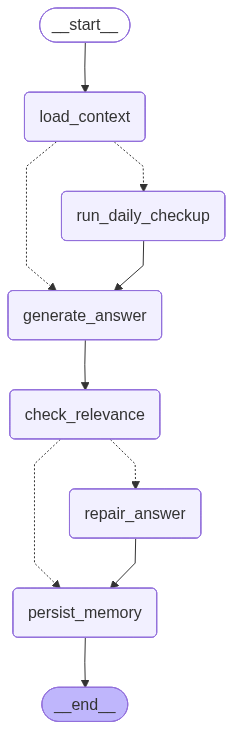

In [11]:
nexus_agent

## Session Management & Public API

In [24]:
# ── Start a new session ─────────────────────────────────────────────────
SESSION_ID = generate_session_id()
print(f"New session: {SESSION_ID}")


def ask_nexus(user_input: str, session_id: str = None) -> str:
    """Send a question to Nexus and get the final answer.
    The checkpointer automatically persists session state via thread_id."""
    sid = session_id or SESSION_ID
    config = get_thread_config(sid)
    result = nexus_agent.invoke({"user_input": user_input}, config=config)
    return result["final_answer"]


def close_session(session_id: str = None):
    """End-of-session: summarize key decisions and write them to Tier 3 (Supermemory).
    Call this when you're done working."""
    sid = session_id or SESSION_ID
    config = get_thread_config(sid)

    # Try to get the latest state from the checkpointer
    try:
        snapshot = nexus_agent.get_state(config)
        state = snapshot.values if snapshot else {}
    except Exception:
        state = {}

    history = state.get("conversation_history", [])
    if not history:
        print("No conversation to summarize.")
        return

    # Build a summary using the LLM
    conversation_text = "\n".join(
        f"{t['role'].upper()}: {t['content']}" for t in history
    )
    messages = [
        SystemMessage(content=(
            "Summarize this conversation into key decisions, new knowledge, "
            "and action items. Be concise. Use bullet points. "
            "Focus on facts worth remembering long-term."
        )),
        HumanMessage(content=conversation_text),
    ]
    summary = llm.invoke(messages).content

    # Write to Tier 3
    knowledge_base.add(
        content=summary,
        metadata={
            "type": "session_summary",
            "session_id": sid,
            "timestamp": datetime.now(timezone.utc).isoformat(),
        },
    )
    print(f"Session {sid} summarized and written to Tier 3.")
    print(f"Summary:\n{summary}")

New session: 10b951b3e273


## Ask Nexus

In [ ]:
print(ask_nexus("i also need to go to the grocery shop, after mailing Dr? what was the name"))

In [ ]:
#print checkpointer storage
config = get_thread_config(SESSION_ID)
snapshot = nexus_agent.get_state(config)
if snapshot and snapshot.values:
    for turn in snapshot.values.get("conversation_history", []):
        print(f"[{turn['role']}]: {turn['content'][:80]}...")


In [26]:
# user_input = input("Ask Nexus: ")
# print(ask_nexus(user_input))

In [ ]:
print(build_system_prompt("test query", {}))

## End Session

Run this cell when you're done. It summarizes the conversation and writes key decisions to Tier 3 (Supermemory).

In [ ]:
close_session()